In [10]:
from transformers import AutoTokenizer

# 1. 최신 환경과 호환성이 좋은 kobert-base-v1 모델 사용
# skt/kobert-base-v1 대신 monologg/kobert를 시도해 보세요.
tokenizer = AutoTokenizer.from_pretrained('monologg/kobert', trust_remote_code=True)

text = "임신해서 우울해"
print(tokenizer.tokenize(text))

config.json:   0%|          | 0.00/426 [00:00<?, ?B/s]

c:\Users\user\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--monologg--kobert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/263 [00:00<?, ?B/s]

tokenization_kobert.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/monologg/kobert:
- tokenization_kobert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_78b3253a26.model:   0%|          | 0.00/371k [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

['▁임신', '해서', '▁우', '울', '해']


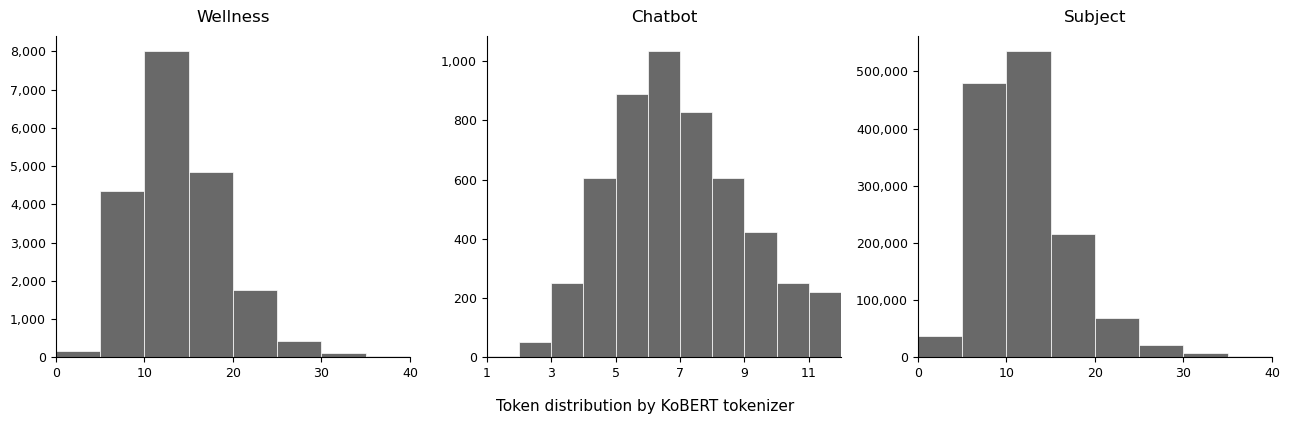

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from transformers import AutoTokenizer

# 1. 토크나이저 로드 (성공하셨던 그 설정 그대로!)
tokenizer = AutoTokenizer.from_pretrained('monologg/kobert', trust_remote_code=True)

# 2. 데이터 로드
wellness = pd.read_csv("cleaned_wellness.csv")
chatbot  = pd.read_csv("cleaned_chatbot.csv")
subject  = pd.read_csv("cleaned_subject.csv")

# 3. 토큰 길이를 계산하는 함수 수정
def get_lengths(df):
    # split() 대신 tokenizer.tokenize를 사용하여 실제 토큰 개수를 계산합니다.
    return df['utterance'].dropna().apply(lambda x: len(tokenizer.tokenize(str(x)))).tolist()

wl = get_lengths(wellness)
cl = get_lengths(chatbot)
sl = get_lengths(subject)

# 💡 참고: KoBERT는 단어를 더 잘게 쪼개기 때문에 기존 bins(눈금) 범위를 넘어갈 수 있습니다.
# 만약 그래프가 잘린다면 bins와 xticks의 숫자를 조금 더 크게 조정해 주세요.
configs = [
    (wl, [0, 5, 10, 15, 20, 25, 30, 35, 40], 'Wellness', [0, 10, 20, 30, 40]),
    (cl, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'Chatbot', [1, 3, 5, 7, 9, 11]),
    (sl, [0, 5, 10, 15, 20, 25, 30, 35, 40], 'Subject', [0, 10, 20, 30, 40]),
]

BAR_COLOR = '#696969'

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (data, bins, title, xticks) in zip(axes, configs):
    counts, edges = np.histogram(data, bins=bins)

    widths = np.diff(edges)
    ax.bar(edges[:-1], counts, width=widths, align='edge',
           color=BAR_COLOR, edgecolor='white', linewidth=0.5)

    ax.set_title(title, fontsize=12, pad=10) # 각 그래프 제목 추가
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks], fontsize=9)
    ax.set_xlim(edges[0], edges[-1])

    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )
    ax.tick_params(axis='both', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.text(0.5, -0.04, 'Token distribution by KoBERT tokenizer',
         ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("fig4_kobert_token_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

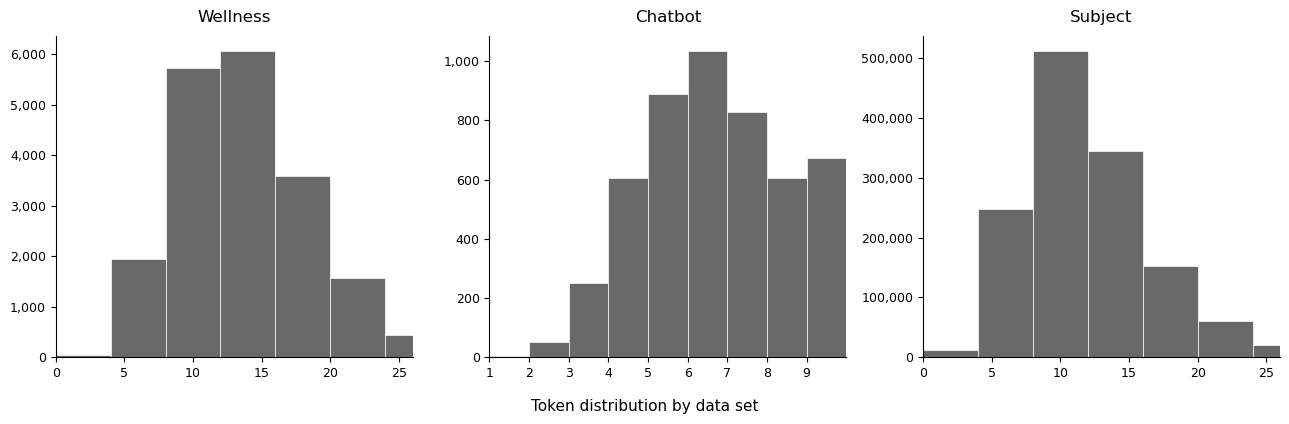

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from transformers import AutoTokenizer

# 1. KoBERT 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained('monologg/kobert', trust_remote_code=True)

# 2. 데이터 로드
wellness = pd.read_csv("cleaned_wellness.csv")
chatbot  = pd.read_csv("cleaned_chatbot.csv")
subject  = pd.read_csv("cleaned_subject.csv")

# 3. 토큰 길이 계산 (KoBERT 적용)
def get_lengths(df):
    return df['utterance'].dropna().apply(lambda x: len(tokenizer.tokenize(str(x)))).tolist()

wl = get_lengths(wellness)
cl = get_lengths(chatbot)
sl = get_lengths(subject)

# 4. 요청하신 원본 bins 및 xticks 설정 유지
# wellness/subject: x눈금 5칸 간격, 막대 4칸마다
# chatbot:          x눈금 1칸 간격, 막대 1칸마다
configs = [
    (wl, [0,4,8,12,16,20,24,26], 'Wellness', [0,5,10,15,20,25]),
    (cl, [1,2,3,4,5,6,7,8,9,10], 'Chatbot',  [1,2,3,4,5,6,7,8,9]),
    (sl, [0,4,8,12,16,20,24,26], 'Subject',  [0,5,10,15,20,25]),
]

BAR_COLOR = '#696969'

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (data, bins, title, xticks) in zip(axes, configs):
    # np.histogram을 통해 데이터 분포 계산
    counts, edges = np.histogram(data, bins=bins)

    widths = np.diff(edges)
    ax.bar(edges[:-1], counts, width=widths, align='edge',
           color=BAR_COLOR, edgecolor='white', linewidth=0.5)

    ax.set_title(title, fontsize=12, pad=10) # 타이틀 추가
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks], fontsize=9)
    ax.set_xlim(edges[0], edges[-1])

    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )
    ax.tick_params(axis='both', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.text(0.5, -0.04, 'Token distribution by data set',
         ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("fig4_token_distribution.png", dpi=150, bbox_inches='tight')
plt.show()